In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')
# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [81]:
df["Дата"] = pd.to_datetime(df["Дата"])
df["Дата"].dtype

dtype('<M8[ns]')

Сгруппируйте данные по дате, посчитайте количество продаж

In [82]:
grouped_df = df.groupby("Дата")["Количество"].sum()

Вывести несколько первых строк сгруппированных данных

In [83]:
grouped_df.head(2)

Дата
2018-01-04    3734
2018-01-05    3643
Name: Количество, dtype: int64

Нарисуйте график продаж у `grouped_df`

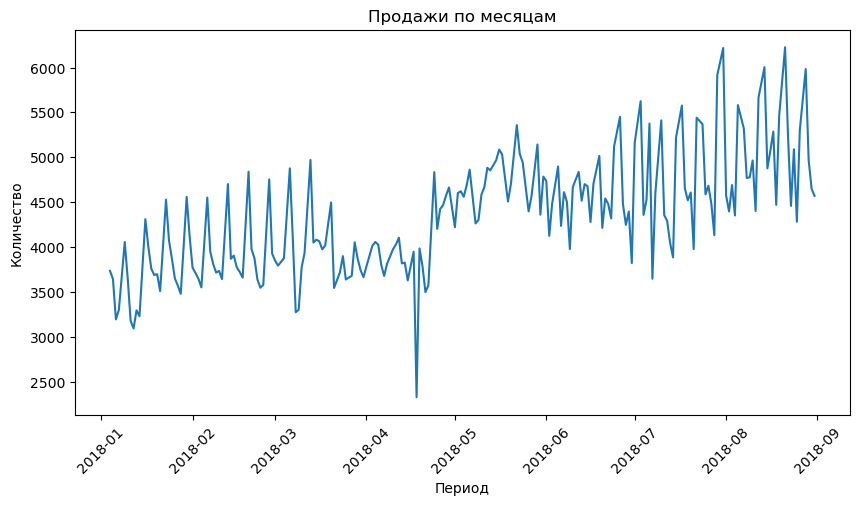

In [84]:
plt.figure(figsize=(10, 5))

plt.plot(grouped_df)
plt.title("Продажи по месяцам")
plt.xlabel("Период")
plt.ylabel("Количество")
plt.xticks(rotation=45)

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
За исключением резкого снижения в апреле и резкого роста к августу, динамика продаж была относительно стабильной, демонстрируя умеренные колебания без резких скачков.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [26]:
df.loc[df["Количество"].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

In [27]:
df.loc[df["Количество"].idxmin()]

Дата            2018-01-04 00:00:00
Склад                             1
Контрагент                address_0
Номенклатура              product_6
Количество                        0
Name: 6, dtype: object

In [31]:
Q1 = df["Количество"].quantile(0.25)
Q3 = df["Количество"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[df["Количество"] > upper_bound]
outliers.loc[outliers["Количество"].idxmax()]
df[df["Количество"] > upper_bound].sort_values("Количество", ascending=False).head(1)

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


In [39]:
Q1 = df["Количество"].quantile(0.25)
Q3 = df["Количество"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

df[df["Количество"] < lower_bound].nsmallest(1, "Количество")

,Дата,Склад,Контрагент,Номенклатура,Количество


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [44]:
df["Дата"] = pd.to_datetime(df["Дата"])
df_summer = df[df["Дата"].dt.month.isin([6, 7, 8])]
df_wed = df_summer[df_summer["Дата"].dt.day_name() == "Wednesday"]
df_filtered = df_wed[df_wed["Склад"] == 3]
result = df_filtered.groupby("Номенклатура")["Количество"].sum()    
top_product = result.sort_values(ascending=False).head(1)
top_product

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [105]:
import pandas as pd
import csv

weather = pd.read_csv(
    "35188utf8.csv.gz",
    sep=";",
    engine="python",
    encoding="utf-8",
    quoting=csv.QUOTE_NONE,
    on_bad_lines="skip"
)

In [106]:
weather

,"# Метеостанция Астана, Казахстан, WMO_ID=35188, выборка с 04.01.2018 по 31.08.2018, все дни"
0,# Кодировка: UTF-8
1,"# Информация предоставлена сайтом ""Расписание ..."
2,"# Пожалуйста, при использовании данных, любезн..."
3,# Обозначения метеопараметров см. по адресу ht...
4,#


In [107]:
weather = pd.read_excel("weatherAstana1.xlsx")


In [73]:
weather


,Дата,Время,T
0,2018-08-31,23:00:00,8.2
1,2018-08-31,20:00:00,9.6
2,2018-08-31,17:00:00,11.3
3,2018-08-31,14:00:00,12.3
4,2018-08-31,11:00:00,13.2
...,...,...,...
1913,2018-01-04,14:00:00,-9.6
1914,2018-01-04,11:00:00,-12.3
1915,2018-01-04,08:00:00,-12.6
1916,2018-01-04,05:00:00,-12.3


In [75]:
grouped_weather = weather.groupby('Дата')['T'].mean()

In [76]:
grouped_weather

Дата
2018-01-04   -14.0750
2018-01-05   -16.8625
2018-01-06   -13.3000
2018-01-07   -12.7500
2018-01-08   -15.4125
               ...   
2018-08-27    12.5250
2018-08-28    14.1125
2018-08-29    13.8250
2018-08-30    14.1750
2018-08-31    11.0250
Name: T, Length: 240, dtype: float64

In [91]:
grouped_weather = grouped_weather.reset_index()

In [92]:
result = grouped_weather.merge(grouped_df, on='Дата')

In [93]:
result

,Дата,T,Количество
0,2018-01-04,-14.0750,3734
1,2018-01-05,-16.8625,3643
2,2018-01-06,-13.3000,3193
3,2018-01-07,-12.7500,3298
4,2018-01-09,-6.2500,4055
...,...,...,...
200,2018-08-26,11.9750,5302
201,2018-08-28,14.1125,5983
202,2018-08-29,13.8250,4969
203,2018-08-30,14.1750,4648


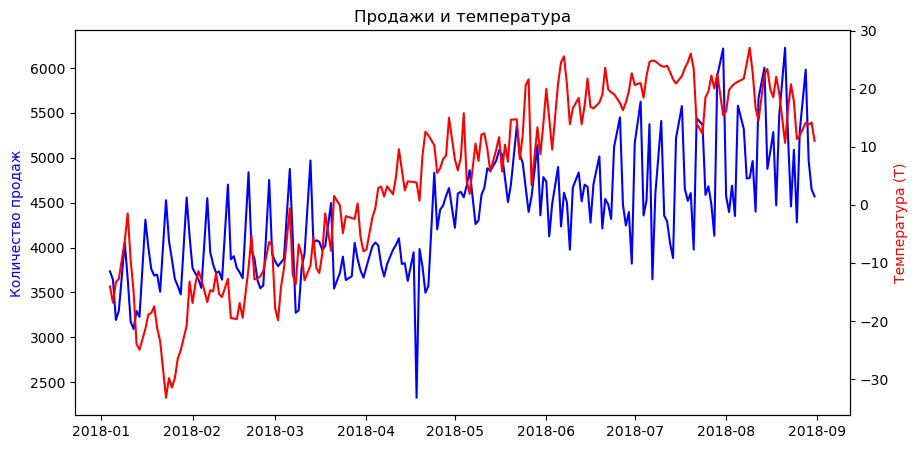

In [104]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(result['Дата'], result['Количество'], color='blue')
ax1.set_ylabel('Количество продаж', color='blue')
ax2 = ax1.twinx()
ax2.plot(result['Дата'], result['T'], color='red')
ax2.set_ylabel('Температура (T)', color='red')
plt.xticks(rotation=45)
plt.title('Продажи и температура')

plt.show()

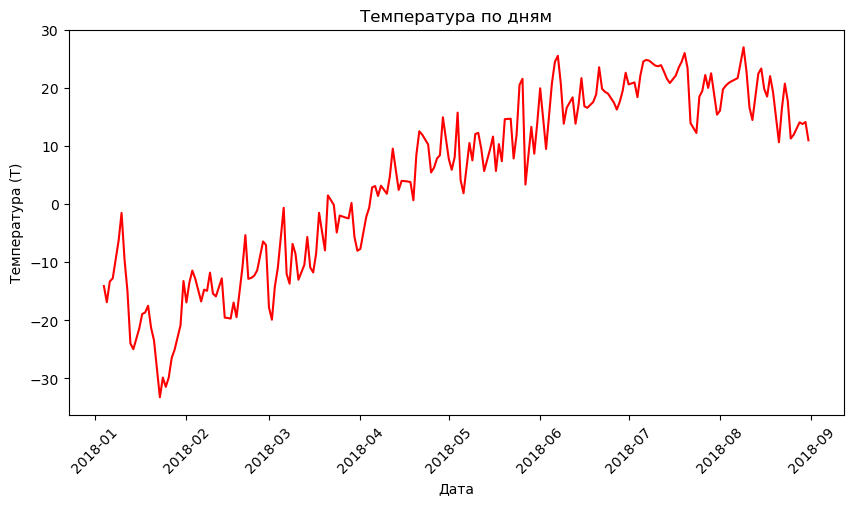

In [108]:
plt.figure(figsize=(10,5))
plt.plot(result['Дата'], result['T'], color='red')
plt.title('Температура по дням')
plt.xlabel('Дата')
plt.ylabel('Температура (T)')
plt.xticks(rotation=45)
plt.show()